In [1]:
# ===========================================
# STEP 0: Setup & Google Drive Mount
# ===========================================
from google.colab import drive
drive.mount('/content/drive')

# --------- User Paths (EDIT ONLY THIS BLOCK) ---------
# Make sure these paths match your files in Google Drive
BASE_DIR   = "/content/drive/MyDrive/Bharat/Chandigarh Project"
AOI_PATH   = "/content/drive/MyDrive/Bharat/Chandigarh Project/chd_boundary.geojson"
LABELS_GJ  = "/content/drive/MyDrive/Bharat/Chandigarh Project/Chandigarh_training.geojson"

# Sentinel-2 (L2A) bands (JP2)
# 2016 (11-Dec-2016)
B02_2016 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2016_Bands/T43RFQ_20161211T053222_B02_10m.jp2"
B03_2016 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2016_Bands/T43RFQ_20161211T053222_B03_10m.jp2"
B04_2016 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2016_Bands/T43RFQ_20161211T053222_B04_10m.jp2"
B08_2016 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2016_Bands/T43RFQ_20161211T053222_B08_10m.jp2"
B11_2016 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2016_Bands/T43RFQ_20161211T053222_B11_20m.jp2"
SCL_2016 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2016_Bands/T43RFQ_20161211T053222_SCL_20m.jp2"

# 2024 (04-Dec-2024)
B02_2024 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2024_Bands/T43RFQ_20241204T053119_B02_10m.jp2"
B03_2024 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2024_Bands/T43RFQ_20241204T053119_B03_10m.jp2"
B04_2024 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2024_Bands/T43RFQ_20241204T053119_B04_10m.jp2"
B08_2024 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2024_Bands/T43RFQ_20241204T053119_B08_10m.jp2"
B11_2024 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2024_Bands/T43RFQ_20241204T053119_B11_20m.jp2"
SCL_2024 = "/content/drive/MyDrive/Bharat/Chandigarh Project/2024_Bands/T43RFQ_20241204T053119_SCL_20m.jp2"

# Processed Sentinel-1 (SAR) GeoTIFFs from SNAP
S1_VV_2016_PATH = "/content/drive/MyDrive/Bharat/Chandigarh Project/S1_2016_processed_Sigma0_VV.tif"
S1_VH_2016_PATH = "/content/drive/MyDrive/Bharat/Chandigarh Project/S1_2016_processed_Sigma0_VH.tif"
S1_VV_2024_PATH = "/content/drive/MyDrive/Bharat/Chandigarh Project/S1_2024_processed_Sigma0_VV.tif"
S1_VH_2024_PATH = "/content/drive/MyDrive/Bharat/Chandigarh Project/S1_2024_processed_Sigma0_VH.tif"

# Output Directories
OUT_DIR    = f"{BASE_DIR}/outputs"
RASTER_DIR = f"{OUT_DIR}/rasters"
VECTOR_DIR = f"{OUT_DIR}/vectors"
TABLE_DIR  = f"{OUT_DIR}/tables"

import os
for d in [OUT_DIR, RASTER_DIR, VECTOR_DIR, TABLE_DIR]:
    os.makedirs(d, exist_ok=True)

Mounted at /content/drive


In [2]:
# ===========================================
# STEP 1: Installs & Imports
# ===========================================
!pip -q install rasterio geopandas shapely scikit-learn pyproj rtree folium matplotlib scipy seaborn

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from shapely.geometry import mapping, shape
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from scipy.ndimage import generic_filter
import folium
import warnings
warnings.filterwarnings("ignore")
import matplotlib.patches as mpatches
from matplotlib import colors
from rasterio.features import shapes
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.6/507.6 kB 12.6 MB/s eta 0:00:00


In [3]:
# ===========================================
# STEP 2: Helper Functions
# ===========================================
def read_band(path):
    return rasterio.open(path)

def resample_to_ref(src_ds, ref_ds, resampling=Resampling.bilinear):
    dst_profile = ref_ds.profile.copy()
    dst_profile.update({"height": ref_ds.height, "width": ref_ds.width, "transform": ref_ds.transform, "crs": ref_ds.crs, "dtype": src_ds.dtypes[0]})
    dst = np.zeros((ref_ds.height, ref_ds.width), dtype=src_ds.dtypes[0])
    reproject(source=rasterio.band(src_ds, 1), destination=dst, src_transform=src_ds.transform, src_crs=src_ds.crs, dst_transform=ref_ds.transform, dst_crs=ref_ds.crs, resampling=resampling)
    return dst, dst_profile

def clip_by_aoi(array, profile, aoi_gdf):
    aoi_proj = aoi_gdf.to_crs(profile["crs"])
    geom = [mapping(geom) for geom in aoi_proj.geometry]
    with rasterio.io.MemoryFile() as memfile:
        with memfile.open(**profile) as ds:
            ds.write(array, 1)
            out_img, out_transform = mask(ds, geom, crop=True)
            out_meta = ds.meta.copy()
            out_meta.update({"height": out_img.shape[1], "width": out_img.shape[2], "transform": out_transform})
    return out_img[0], out_meta

def write_tif(path, array, profile, nodata=None):
    meta = profile.copy()
    meta.update(count=1 if array.ndim == 2 else array.shape[0])
    if nodata is not None: meta.update(nodata=nodata)
    with rasterio.open(path, "w", **meta) as ds:
        ds.write(array, 1 if array.ndim == 2 else None)

def add_indices_stack(b02, b03, b04, b08, b11):
    b02, b03, b04, b08, b11 = map(lambda x: x.astype("float32"), [b02, b03, b04, b08, b11])
    eps = 1e-6
    ndvi  = (b08 - b04) / (b08 + b04 + eps)
    ndbi  = (b11 - b08) / (b11 + b08 + eps)
    mndwi = (b03 - b11) / (b03 + b11 + eps)
    return np.stack([b02, b03, b04, b08, b11, ndvi, ndbi, mndwi], axis=0)

def majority_filter(labels2d, size=3):
    def mode_fun(x):
        vals, counts = np.unique(x, return_counts=True)
        return vals[np.argmax(counts)]
    return generic_filter(labels2d, mode_fun, size=size)

def scl_cloud_mask(scl_array):
    bad = np.isin(scl_array, [3, 4, 8, 9, 10, 11])
    return ~bad

def reproject_geo(gdf, epsg):
    return gdf.to_crs(epsg)

In [4]:
# ===========================================
# STEP 3: Load AOI & Reproject
# ===========================================
aoi_gdf = gpd.read_file(AOI_PATH)
aoi_utm = reproject_geo(aoi_gdf, 32643)

--- Preparing 2016 ---


Reading and stacking Sentinel-1 bands for 2016...


Final stack for 2016 created with shape: (10, 1001, 1149)


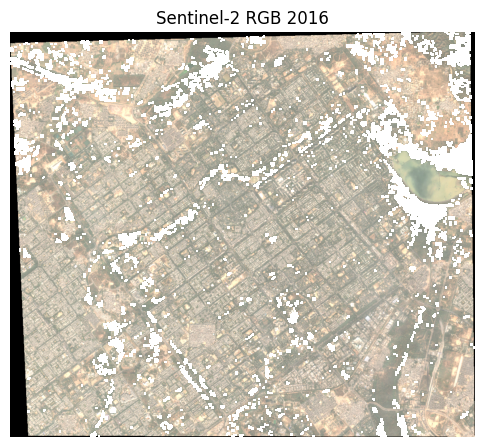

--- Preparing 2024 ---


Reading and stacking Sentinel-1 bands for 2024...


Final stack for 2024 created with shape: (10, 1001, 1149)


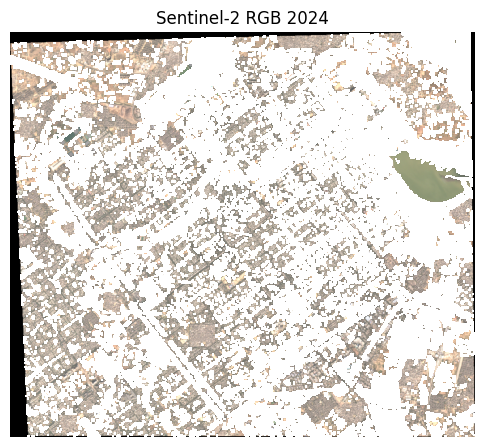

In [5]:
# ===========================================
# STEP 4: Prepare Data Stacks (S2 + S1)
# ===========================================
def prepare_year(b02_p, b03_p, b04_p, b08_p, b11_p, scl_p, s1_vv_p, s1_vh_p, aoi_utm, tag):
    print(f"--- Preparing {tag} ---")
    ref = read_band(b08_p)
    b02, _ = resample_to_ref(read_band(b02_p), ref)
    b03, _ = resample_to_ref(read_band(b03_p), ref)
    b04, _ = resample_to_ref(read_band(b04_p), ref)
    b08, ref_prof = resample_to_ref(read_band(b08_p), ref)
    b11, _ = resample_to_ref(read_band(b11_p), ref)
    scl, _ = resample_to_ref(read_band(scl_p), ref, resampling=Resampling.nearest)
    b02_clip, prof = clip_by_aoi(b02, ref_prof, aoi_utm)
    clips = [clip_by_aoi(band, ref_prof, aoi_utm)[0] for band in [b03, b04, b08, b11, scl]]
    b03_clip, b04_clip, b08_clip, b11_clip, scl_clip = clips
    good_mask = scl_cloud_mask(scl_clip)
    def mask_s2_bad_pixels(x):
        x = x.astype("float32")
        x[~good_mask] = np.nan
        return x
    s2_bands_masked = [mask_s2_bad_pixels(b) for b in [b02_clip, b03_clip, b04_clip, b08_clip, b11_clip]]
    s2_stack = add_indices_stack(*s2_bands_masked)
    print(f"Reading and stacking Sentinel-1 bands for {tag}...")
    with read_band(s1_vv_p) as ds:
        vv_resampled, _ = resample_to_ref(ds, ref)
        vv_clipped, _ = clip_by_aoi(vv_resampled, ref_prof, aoi_utm)
    with read_band(s1_vh_p) as ds:
        vh_resampled, _ = resample_to_ref(ds, ref)
        vh_clipped, _ = clip_by_aoi(vh_resampled, ref_prof, aoi_utm)
    s1_vv_stack = vv_clipped.astype('float32')
    s1_vh_stack = vh_clipped.astype('float32')
    final_stack = np.vstack([s2_stack, s1_vv_stack[np.newaxis, :, :], s1_vh_stack[np.newaxis, :, :]])
    print(f"Final stack for {tag} created with shape: {final_stack.shape}")
    rgb = np.dstack([s2_bands_masked[2], s2_bands_masked[1], s2_bands_masked[0]])
    rgb_norm = np.clip((rgb - np.nanpercentile(rgb, 2)) / (np.nanpercentile(rgb, 98) - np.nanpercentile(rgb, 2) + 1e-6), 0, 1)
    plt.figure(figsize=(6,6)); plt.imshow(rgb_norm); plt.title(f"Sentinel-2 RGB {tag}"); plt.axis('off'); plt.show()
    return final_stack, prof, good_mask

stack2016, prof2016, good2016 = prepare_year(B02_2016, B03_2016, B04_2016, B08_2016, B11_2016, SCL_2016, S1_VV_2016_PATH, S1_VH_2016_PATH, aoi_utm, "2016")
stack2024, prof2024, good2024 = prepare_year(B02_2024, B03_2024, B04_2024, B08_2024, B11_2024, SCL_2024, S1_VV_2024_PATH, S1_VH_2024_PATH, aoi_utm, "2024")


In [6]:
# ===========================================
# STEP 5: Load Training Polygons & Sample Pixels
# ===========================================
label_gdf = gpd.read_file(LABELS_GJ)
CLASS_MAP = {"Built-Up":1, "Vegetation":2, "Water":3, "Barren":4}
# **FIX IS HERE**: Define class_labels right after CLASS_MAP
class_labels = {1: "Built-Up", 2: "Vegetation", 3: "Water", 4: "Barren"}
label_gdf["cls_id"] = label_gdf["class"].map(CLASS_MAP)
label_gdf = label_gdf.dropna(subset=["cls_id"]).to_crs(prof2016["crs"])

def sample_from_polygons(stack, profile, gdf, max_samples_per_class=20000):
    H, W = stack.shape[1], stack.shape[2]
    affine = profile["transform"]
    X_list, y_list = [], []
    from rasterio.features import geometry_mask
    for cls_name, cls_id in CLASS_MAP.items():
        sub = gdf[gdf["cls_id"] == cls_id]
        if sub.empty: continue
        mask_arr = ~geometry_mask([mapping(g) for g in sub.geometry], transform=affine, invert=True, out_shape=(H, W))
        valid = mask_arr & np.all(~np.isnan(stack), axis=0)
        ys, xs = np.where(valid)
        if len(ys) == 0: continue
        idx = np.random.choice(np.arange(len(ys)), size=min(max_samples_per_class, len(ys)), replace=False)
        feats = stack[:, ys[idx], xs[idx]].T
        X_list.append(feats)
        y_list.append(np.full((feats.shape[0],), cls_id))
        print(f"Class {cls_name}: sampled {feats.shape[0]} pixels")
    if not X_list: raise RuntimeError("No training samples found.")
    return np.vstack(X_list), np.concatenate(y_list)

X_train, y_train = sample_from_polygons(stack2016, prof2016, label_gdf)


Class Built-Up: sampled 20000 pixels
Class Vegetation: sampled 20000 pixels
Class Water: sampled 20000 pixels
Class Barren: sampled 20000 pixels


In [8]:
# #############################################################################
# STEP 6: Train and Split the Data

clf = RandomForestClassifier(n_estimators=400, n_jobs=-1, class_weight="balanced", random_state=42)

# Split the data into training and testing sets
X_train_split, X_test, y_train_split, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Print sample sizes
print(f"Total Labeled Samples: {len(y_train)}")
print(f"Training Samples (80%): {len(y_train_split)}")
print(f"Testing Samples (20%): {len(y_test)}")

# Train the model
print("\n--- Training model... ---")
clf.fit(X_train_split, y_train_split)

print("Model training complete.")

Total Labeled Samples: 80000
Training Samples (80%): 64000
Testing Samples (20%): 16000

--- Training model... ---
Model training complete.


Classifying 1150149 pixels for 2016...
✅ Saved classified map: /content/drive/MyDrive/Bharat/Chandigarh Project/outputs/rasters/classified_2016.tif
Classifying 1150149 pixels for 2024...
✅ Saved classified map: /content/drive/MyDrive/Bharat/Chandigarh Project/outputs/rasters/classified_2024.tif


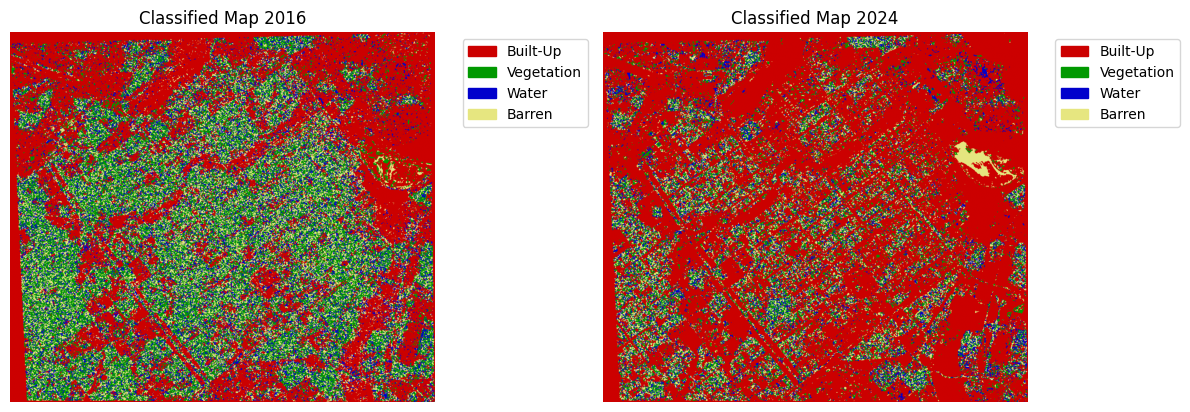

In [9]:
# ===========================================
# STEP 7: Predict, Smooth, Save, and Plot
# ===========================================
class_colors = {1: (0.8, 0.0, 0.0), 2: (0.0, 0.6, 0.0), 3: (0.0, 0.0, 0.8), 4: (0.9, 0.9, 0.5)}

def predict_map(stack, profile, tag):
    C, H, W = stack.shape
    flat = stack.reshape(C, -1).T
    valid_mask = ~np.isnan(flat[:, -1])
    data_to_predict = flat[valid_mask]
    data_to_predict = np.nan_to_num(data_to_predict, nan=0.0)
    preds = np.zeros(flat.shape[0], dtype=np.uint8)
    print(f"Classifying {len(data_to_predict)} pixels for {tag}...")
    preds[valid_mask] = clf.predict(data_to_predict).astype(np.uint8)
    pred2d = preds.reshape(H, W)
    smooth = majority_filter(pred2d, size=3).astype(np.uint8)
    prof_out = profile.copy()
    prof_out.update(dtype="uint8", count=1, nodata=0)
    out_path = f"{RASTER_DIR}/classified_{tag}.tif"
    write_tif(out_path, smooth, prof_out, nodata=0)
    print(f"✅ Saved classified map: {out_path}")
    return smooth, prof_out

pred2016, prof2016_out = predict_map(stack2016, prof2016, "2016")
pred2024, prof2024_out = predict_map(stack2024, prof2024, "2024")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
cmap = colors.ListedColormap([class_colors[i] for i in sorted(class_colors)])
for ax, data, year in zip(axes, [pred2016, pred2024], [2016, 2024]):
    ax.imshow(data, cmap=cmap, vmin=1, vmax=len(class_colors))
    ax.set_title(f"Classified Map {year}")
    ax.axis("off")
    patches = [mpatches.Patch(color=c, label=l) for l, c in zip(class_labels.values(), class_colors.values())]
    ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.show()

✅ Saved change map: /content/drive/MyDrive/Bharat/Chandigarh Project/outputs/rasters/change_2016_2024.tif


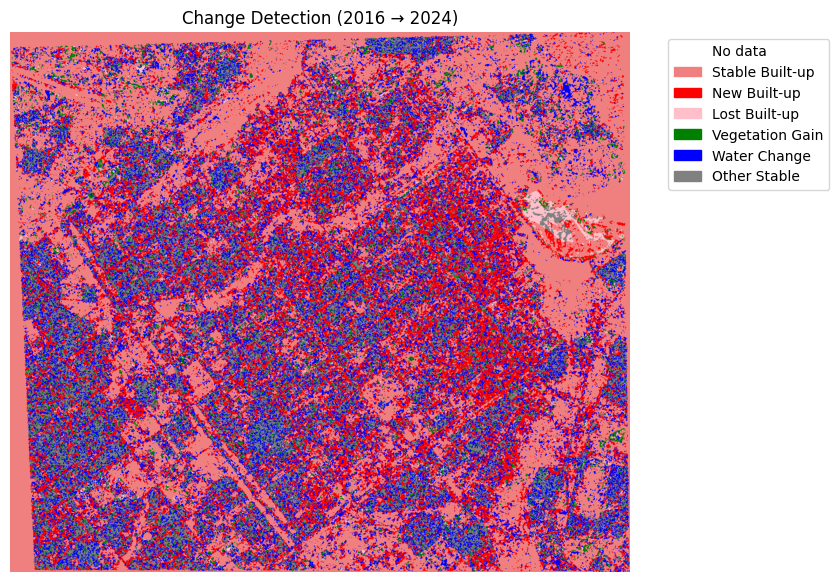


--- From-To Change Matrix (Area in km²) ---


2024,Built-Up,Vegetation,Water,Barren
2016,,,,
Built-Up,43.9159,2.1372,1.6524,1.3775
Vegetation,14.1042,5.9720,4.0373,4.7800
Water,10.6557,2.7443,1.9751,2.0707
Barren,10.8152,3.4936,2.3297,2.9541


In [10]:
# ===========================================
# STEP 8: Change Detection & From-To Matrix
# ===========================================
def change_map_from(pred16, pred24):
    out = np.zeros_like(pred16, dtype=np.uint8)
    built = (pred16 == 1); non_built = np.isin(pred16, [2, 3, 4])
    built24 = (pred24 == 1)
    out[built & built24] = 10
    out[non_built & built24] = 11
    out[built & ~built24] = 12
    out[(pred24 == 2) & (pred16 != 2)] = 13
    out[(pred16 == 3) ^ (pred24 == 3)] = 14
    valid = (pred16 != 0) & (pred24 != 0) & (out == 0)
    out[valid] = 15
    return out

chg = change_map_from(pred2016, pred2024)
chg_path = f"{RASTER_DIR}/change_2016_2024.tif"
write_tif(chg_path, chg, prof2016_out, nodata=0)
print(f"✅ Saved change map: {chg_path}")

from matplotlib.colors import ListedColormap, BoundaryNorm
change_cmap = {0: ("white", "No data"), 10: ("lightcoral", "Stable Built-up"), 11: ("red", "New Built-up"), 12: ("pink", "Lost Built-up"), 13: ("green", "Vegetation Gain"), 14: ("blue", "Water Change"), 15: ("gray", "Other Stable")}
cmap = ListedColormap([c[0] for c in change_cmap.values()])
norm = BoundaryNorm(list(change_cmap.keys()) + [max(change_cmap.keys()) + 1], cmap.N)
plt.figure(figsize=(8, 8)); plt.imshow(chg, cmap=cmap, norm=norm);
plt.title("Change Detection (2016 → 2024)"); plt.axis("off")
handles = [mpatches.Patch(color=c, label=l) for c, l in change_cmap.values()]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left'); plt.show()

# From-To Matrix
from_to_matrix = pd.crosstab(pd.Series(pred2016.ravel(), name='2016'), pd.Series(pred2024.ravel(), name='2024'))
all_labels = {0: "NoData", **class_labels}
from_to_matrix.index = from_to_matrix.index.map(all_labels.get)
from_to_matrix.columns = from_to_matrix.columns.map(all_labels.get)
from_to_matrix_km2 = from_to_matrix * 0.0001
print("\n--- From-To Change Matrix (Area in km²) ---")
display(from_to_matrix_km2)

In [11]:
# ===========================================
# STEP 9: Area Statistics (km²)
# ===========================================
PIX2KM2 = 0.0001
def area_by_class(raster2d, name):
    unique_classes = np.unique(raster2d)
    rows = [{"class_id": c, "class_name": all_labels.get(c, "Unknown"), "pixels": np.sum(raster2d == c), "area_km2": np.sum(raster2d == c) * PIX2KM2} for c in unique_classes]
    df = pd.DataFrame(rows)
    df.to_csv(f"{TABLE_DIR}/area_by_class_{name}.csv", index=False)
    return df

def area_change(chg2d):
    change_names = {10:"Stable_BU", 11:"New_BU", 12:"Lost_BU", 13:"Veg_Gain", 14:"Water_Change", 15:"Other_Stable"}
    unique_changes = np.unique(chg2d)
    rows = [{"change_code": c, "change_name": change_names.get(c, "Unknown"), "pixels": np.sum(chg2d == c), "area_km2": np.sum(chg2d == c) * PIX2KM2} for c in unique_changes if c != 0]
    df = pd.DataFrame(rows)
    df.to_csv(f"{TABLE_DIR}/change_summary_2016_2024.csv", index=False)
    return df

print("\n--- 2016 Class Areas (km²) ---"); display(area_by_class(pred2016, "2016"))
print("\n--- 2024 Class Areas (km²) ---"); display(area_by_class(pred2024, "2024"))
print("\n--- Change Summary (km²) ---"); display(area_change(chg))


--- 2016 Class Areas (km²) ---


,class_id,class_name,pixels,area_km2
0,1,Built-Up,490830,49.0830
1,2,Vegetation,288935,28.8935
2,3,Water,174458,17.4458
3,4,Barren,195926,19.5926



--- 2024 Class Areas (km²) ---


,class_id,class_name,pixels,area_km2
0,1,Built-Up,794910,79.4910
1,2,Vegetation,143471,14.3471
2,3,Water,99945,9.9945
3,4,Barren,111823,11.1823



--- Change Summary (km²) ---


,change_code,change_name,pixels,area_km2
0,10,Stable_BU,439159,43.9159
1,11,New_BU,249194,24.9194
2,12,Lost_BU,13775,1.3775
3,13,Veg_Gain,56308,5.6308
4,14,Water_Change,234901,23.4901
5,15,Other_Stable,156812,15.6812


✅ New development polygons saved: /content/drive/MyDrive/Bharat/Chandigarh Project/outputs/vectors/new_builtup_2016_2024.geojson


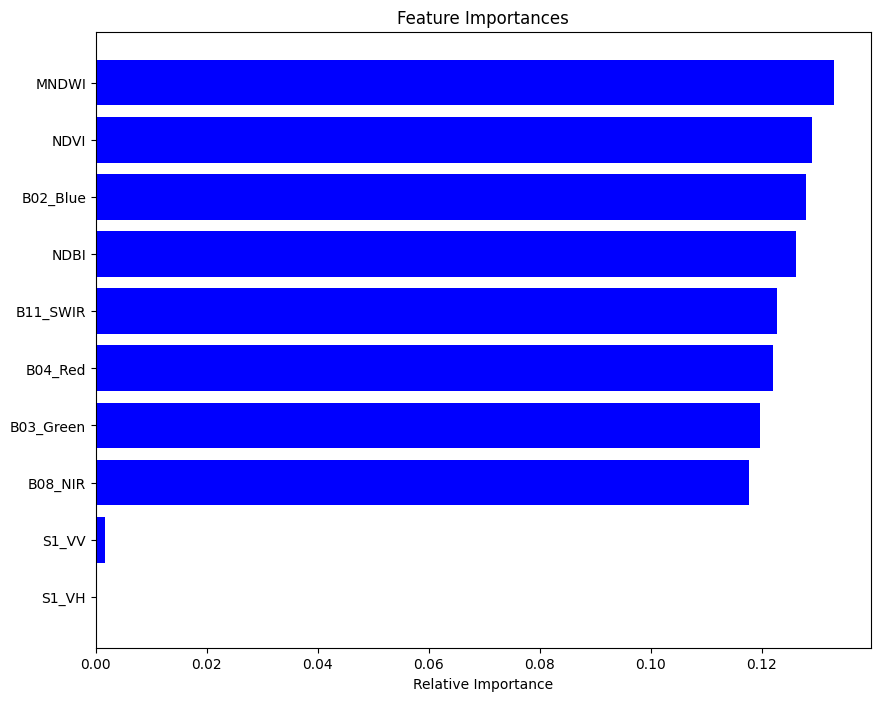

In [12]:
# ===========================================
# STEP 10: Vectorize New Development & Feature Importance
# ===========================================
def raster_to_polygons(mask2d, profile, min_pixels=30):
    transform = profile["transform"]
    min_area = min_pixels * (transform.a ** 2)
    results = [shape(geom) for geom, val in shapes(mask2d.astype(np.uint8), mask=mask2d, transform=transform) if shape(geom).area >= min_area]
    if not results: return gpd.GeoDataFrame(geometry=[], crs=profile["crs"])
    return gpd.GeoDataFrame(geometry=results, crs=profile["crs"])

new_bu_mask = (chg == 11)
gdf_new = raster_to_polygons(new_bu_mask, prof2016_out)
gdf_new_wgs = gdf_new.to_crs(4326)
new_geojson = f"{VECTOR_DIR}/new_builtup_2016_2024.geojson"
gdf_new_wgs.to_file(new_geojson, driver="GeoJSON")
print(f"✅ New development polygons saved: {new_geojson}")

# Feature Importance
feature_names = ['B02_Blue', 'B03_Green', 'B04_Red', 'B08_NIR', 'B11_SWIR', 'NDVI', 'NDBI', 'MNDWI', 'S1_VV', 'S1_VH']
importances = clf.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(10, 8)); plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance'); plt.show()

In [13]:
# ===========================================
# STEP 11: Folium Webmap
# ===========================================
cent = aoi_utm.to_crs(4326).geometry.unary_union.centroid
m = folium.Map(location=[cent.y, cent.x], zoom_start=12, tiles="CartoDB positron")
folium.GeoJson(aoi_utm.to_crs(4326), name="AOI Boundary", style_function=lambda x:{"color": "black", "weight": 2, "fillOpacity": 0}).add_to(m)
folium.GeoJson(new_geojson, name="New Built-up (2016→2024)", style_function=lambda x:{"color":"red","weight":1,"fillColor":"red","fillOpacity":0.5}).add_to(m)
folium.LayerControl().add_to(m)
m